Mini Project: Nightingale Mortality Analysis
This project analyzes mortality data from the British Army during the Crimean War using Python.

The goal is to explore the dataset, perform basic data cleaning, and create visualizations that help explain the causes of soldier mortality.

The visualizations reproduce the famous Coxcomb diagram created by Florence Nightingale to demonstrate that disease was the primary cause of death among soldiers.

1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

2. Load Dataset

import pandas as pd

file_path1 = 'raw_night_1854_1855.xlsx'
file_path2 = 'raw_night_1855_1856.xlsx'

# Load the Excel file using Pandas
df1 = pd.read_excel(file_path1)
df2 = pd.read_excel(file_path2)

print (df1.head())
print (df2.head())

3. Structure of the data set

In [3]:
df1.info()
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Month           12 non-null     object
 1   Avg Army Size   12 non-null     int64 
 2   Disease Deaths  12 non-null     int64 
 3   Wounds          12 non-null     int64 
 4   Other Causes    12 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 608.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Month           12 non-null     object
 1   Avg Army Size   12 non-null     int64 
 2   Disease Deaths  12 non-null     int64 
 3   Wounds          12 non-null     int64 
 4   Other Causes    12 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 608.0+ bytes


3b. Check Columns

In [6]:
print(df1.columns.tolist())


print(df2.columns.tolist())

['Month', 'Avg Army Size', 'Disease Deaths', 'Wounds', 'Other Causes']
['Month', 'Avg Army Size', 'Disease Deaths', 'Wounds', 'Other Causes']


4. Summary statistics

In [7]:
# Display both statistics tables
display(df1.describe())

display(df2.describe())

,Avg Army Size,Disease Deaths,Wounds,Other Causes
count,12.000000,12.000000,12.000000,12.000000
mean,27943.333333,929.916667,64.333333,113.750000
std,6614.656115,882.871087,84.939907,120.929826
min,8571.000000,1.000000,0.000000,5.000000
25%,28135.500000,272.250000,0.000000,19.500000
50%,30268.000000,808.000000,37.000000,88.000000
75%,31080.500000,1336.500000,90.750000,141.250000
max,32393.000000,2761.000000,287.000000,361.000000


,Avg Army Size,Disease Deaths,Wounds,Other Causes
count,12.000000,12.000000,12.000000,12.000000
mean,40672.583333,276.583333,25.083333,27.083333
std,7753.075278,249.483998,17.619505,18.894243
min,32393.000000,15.000000,0.000000,2.000000
25%,35367.750000,78.750000,11.750000,12.250000
50%,36454.000000,183.500000,30.500000,32.000000
75%,47027.750000,478.500000,37.250000,37.000000
max,53321.000000,802.000000,48.000000,57.000000


5. Missing values

In [8]:
print(df1.isnull().sum)

print(df2.isnull().sum)

<bound method NDFrame._add_numeric_operations.<locals>.sum of     Month  Avg Army Size  Disease Deaths  Wounds  Other Causes
0   False          False           False   False         False
1   False          False           False   False         False
2   False          False           False   False         False
3   False          False           False   False         False
4   False          False           False   False         False
5   False          False           False   False         False
6   False          False           False   False         False
7   False          False           False   False         False
8   False          False           False   False         False
9   False          False           False   False         False
10  False          False           False   False         False
11  False          False           False   False         False>
<bound method NDFrame._add_numeric_operations.<locals>.sum of     Month  Avg Army Size  Disease Deaths  Wounds  Other 

6. Create Mortality rate

In [27]:
import pandas as pd
import numpy as np

# 1. Ensure you have the datasets and rates calculated
for df in [df1, df2]:
    # (Optional: recalculate rates if not done in the current cell)
    df["Disease_rate"] = df["Disease Deaths"] / df["Avg Army Size"] * 1000
    df["Wounds_rate"] = df["Wounds"] / df["Avg Army Size"] * 1000
    df["Other_rate"] = df["Other Causes"] / df["Avg Army Size"] * 1000
    
    # 2. CONVERT TO AREA VALUES (Square root of the rates)
    df["Disease_area"] = np.sqrt(df["Disease_rate"])
    df["Wounds_area"] = np.sqrt(df["Wounds_rate"])
    df["Other_area"] = np.sqrt(df["Other_rate"])

# Display df1 results
print("--- 1854-1855 Area Values ---")
display(df1[["Month", "Disease_rate", "Disease_area"]].head())

# Add this to see df2 results
print("--- 1855-1856 Area Values ---")
display(df2[["Month", "Disease_rate", "Disease_area"]].head())

--- 1854-1855 Area Values ---


,Month,Disease_rate,Disease_area
0,Apr 1855,14.725404,3.837369
1,May 1855,14.232483,3.772596
2,Jun 1855,19.923981,4.463629
3,Jul 1855,10.674565,3.267195
4,Aug 1855,9.456867,3.075202


--- 1855-1856 Area Values ---


,Month,Disease_rate,Disease_area
0,Apr 1855,14.725404,3.837369
1,May 1855,14.232483,3.772596
2,Jun 1855,19.923981,4.463629
3,Jul 1855,10.674565,3.267195
4,Aug 1855,9.456867,3.075202


Data Visualisation


Create Plot function

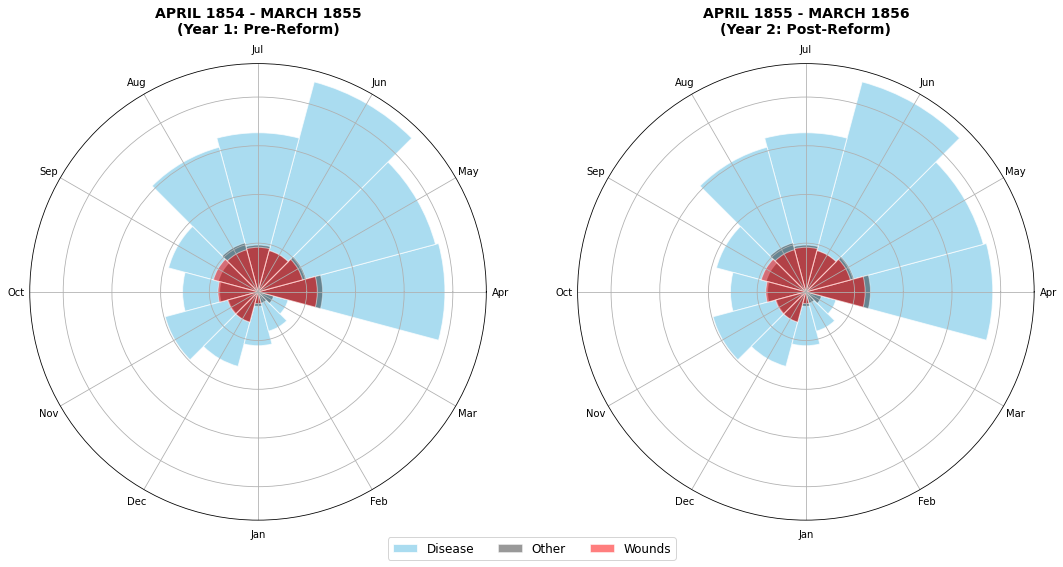

Success! Your chart has been saved as 'Nightingale_Final_Comparison.png'


In [32]:
import matplotlib.pyplot as plt
import numpy as np

def draw_rose(ax, df, title):
    n = len(df)
    theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
    width = (2 * np.pi) / n
    
    # Using the Area columns ensures the visual scale matches Nightingale's original
    ax.bar(theta, df['Disease_area'], width=width, color='skyblue', alpha=0.7, label='Disease', edgecolor='white')
    ax.bar(theta, df['Other_area'], width=width, color='black', alpha=0.4, label='Other', edgecolor='white')
    ax.bar(theta, df['Wounds_area'], width=width, color='red', alpha=0.5, label='Wounds', edgecolor='white')
    
    # Monthly labels
    ax.set_xticks(theta)
    ax.set_xticklabels([m[:3] for m in df['Month']], fontsize=10)
    ax.set_yticklabels([]) # Removes the radial grid numbers for a cleaner look
    ax.set_title(title, fontsize=14, pad=30, fontweight='bold')

# 1. Create the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9), subplot_kw={'projection': 'polar'})

# 2. Draw both years
draw_rose(ax1, df1, "APRIL 1854 - MARCH 1855\n(Year 1: Pre-Reform)")
draw_rose(ax2, df2, "APRIL 1855 - MARCH 1856\n(Year 2: Post-Reform)")

# 3. Add Legend
plt.legend(loc='lower center', bbox_to_anchor=(-0.1, -0.1), ncol=3, fontsize=12)

# 4. SAVE THE IMAGE
# dpi=300 makes it high-resolution for printing/documents
plt.savefig('Nightingale_Final_Comparison.png', dpi=300, bbox_inches='tight')

# 5. Show it in your notebook
plt.show()

print("Success! Your chart has been saved as 'Nightingale_Final_Comparison.png'")

Final Reflection

This project involved the reconstruction of Florence Nightingale's seminal coxcomb diagram utilizing Python, alongside an in-depth analysis of mortality data from the Crimean War through four complementary visual representations. A prominent pattern evident across all visualizations is the predominance of disease as the leading cause of death, particularly pronounced during the winter months of 1854–1855. Disease-related fatalities peaked at over 2,700 in January 1855, significantly surpassing deaths due to wounds and other causes. When adjusted per 1,000 soldiers, the mortality rate from disease reached alarmingly high levels, indicating that preventable illnesses accounted for a substantially greater number of deaths than battlefield injuries.

Equally noteworthy is the data from the subsequent period (1855–1856), which reveals a marked and sustained reduction in mortality across all categories following the establishment of the Sanitary Commission in March 1855. This stark contrast between the two intervals encapsulates Nightingale’s central thesis: that enhancements in hospital hygiene and sanitation practices could save thousands of lives. The empirical evidence robustly corroborates this assertion, as monthly death rates declined to near zero by early 1856. These results underscore the critical importance of public health infrastructure and sanitation as among the most effective interventions for reducing mortality within large populations, whether military or civilian.